/tmp/ipython-input-2576798048.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette='viridis')


Chart created! Download 'alc_chart.png' and upload it to GitHub.


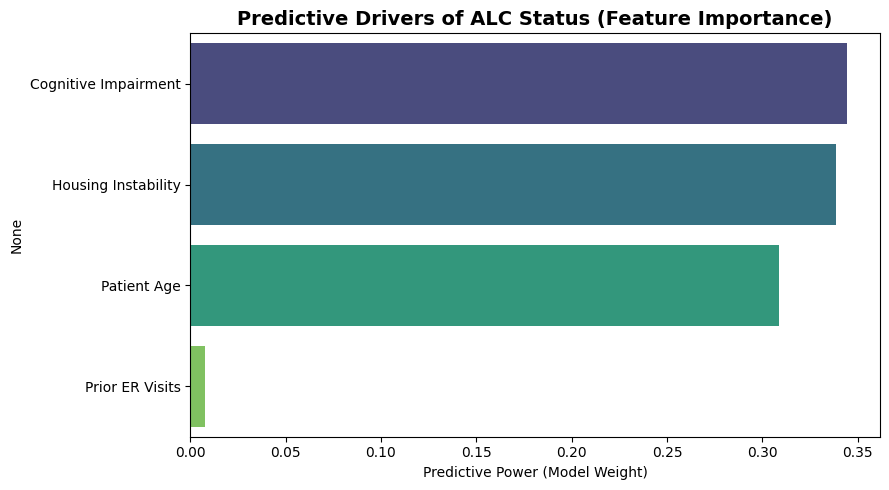

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# 1. SETUP: Generate Synthetic Data (Equity Focus)
np.random.seed(42)
n_patients = 1000
df = pd.DataFrame({
    'Age': np.random.normal(75, 10, n_patients).astype(int),
    # Renaming variables to match your "Structural Competency" narrative
    'Cognitive_Impairment': np.random.choice([0, 1], n_patients, p=[0.7, 0.3]),
    'Housing_Instability': np.random.choice([0, 1], n_patients, p=[0.6, 0.4]),
    'Prior_ER_Visits': np.random.randint(0, 5, n_patients)
})

# Define Risk Logic (Housing & Cognitive issues drive the ALC flag)
def get_risk(row):
    risk = 0
    if row['Age'] > 80: risk += 20
    if row['Cognitive_Impairment'] == 1: risk += 40
    if row['Housing_Instability'] == 1: risk += 35 # High weight for housing
    return 1 if risk > 50 else 0

df['ALC_Risk_Flag'] = df.apply(get_risk, axis=1)

# 2. TRAIN MODEL
X = df[['Age', 'Cognitive_Impairment', 'Housing_Instability', 'Prior_ER_Visits']]
y = df['ALC_Risk_Flag']
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X, y)

# 3. VISUALIZE (The Portfolio Asset)
plt.figure(figsize=(9, 5))
# Extract importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
# Rename index for a professional look on the chart
importances.index = ['Cognitive Impairment', 'Housing Instability', 'Patient Age', 'Prior ER Visits']

# Plot
sns.barplot(x=importances, y=importances.index, palette='viridis')
plt.title('Predictive Drivers of ALC Status (Feature Importance)', fontsize=14, weight='bold')
plt.xlabel('Predictive Power (Model Weight)', fontsize=10)
plt.tight_layout()

# Save
plt.savefig('alc_chart.png', dpi=300)
print("Chart created! Download 'alc_chart.png' and upload it to GitHub.")